In [ ]:
from google.colab import files
uploaded = files.upload()

import zipfile
import os

with zipfile.ZipFile("mix20_rand700_tokens_cleaned.zip", 'r') as zip_ref:
    zip_ref.extractall()

print(os.listdir())
print(os.listdir("tokens"))
print(os.listdir("tokens/pos")[:5])
print(os.listdir("tokens/neg")[:5])

Saving mix20_rand700_tokens_cleaned.zip to mix20_rand700_tokens_cleaned.zip
['.config', 'README', 'mix20_rand700_tokens_cleaned.zip', 'tokens', 'sample_data']
['neg', 'pos']
['cv417_tok-15007.txt', 'cv305_tok-14336.txt', 'cv242_tok-12762.txt', 'cv270_tok-29235.txt', 'cv185_tok-15956.txt']
['cv577_tok-13758.txt', 'cv463_tok-17950.txt', 'cv529_tok-13939.txt', 'cv688_tok-29384.txt', 'cv548_tok-22663.txt']


In [ ]:
texts = []
true_labels = []

base_path = "tokens"

for folder, label in [("pos", 1), ("neg", 0)]:
    folder_path = os.path.join(base_path, folder)

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        with open(file_path, "r", encoding="latin-1") as f:
            texts.append(f.read())
            true_labels.append(label)

print("Total samples:", len(texts))

Total samples: 1400


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=8000,
    stop_words='english',
    min_df=3,
    max_df=0.6,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(texts)

In [ ]:
from sklearn.preprocessing import normalize
X = normalize(X)


In [ ]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100)
X_reduced = svd.fit_transform(X)


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_reduced)

In [ ]:
from sklearn.metrics import accuracy_score

acc1 = accuracy_score(true_labels, kmeans_labels)
acc2 = accuracy_score(true_labels, 1 - kmeans_labels)

print("Best Accuracy:", max(acc1, acc2))

Best Accuracy: 0.5157142857142857


In [ ]:
import numpy as np

terms = vectorizer.get_feature_names_out()
centroids = kmeans.cluster_centers_

for i in range(2):
    top_indices = centroids[i].argsort()[-10:][::-1]
    top_words = [terms[ind] for ind in top_indices]
    print(f"\nCluster {i} top words:")
    print(top_words)


Cluster 0 top words:
['00', '100', '105 minutes', '15', '101', '000', '16', '1960s', '137', '102']

Cluster 1 top words:
['00', '10', '007', '10 scale', '14', '10 minutes', '10 10', '100 minutes', '1968', '11']


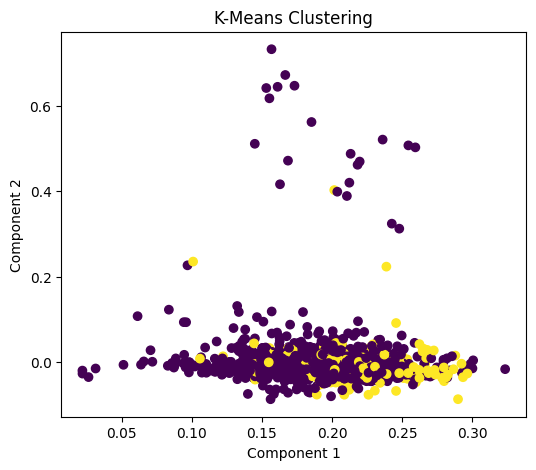

ValueError: X has 100 features, but TruncatedSVD is expecting 8000 features as input.

In [ ]:
svd_2d = TruncatedSVD(n_components=2)
X_2d = svd_2d.fit_transform(X)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_labels)
plt.title("K-Means Clustering")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

# Centroids visualization
centroids_2d = svd_2d.transform(kmeans.cluster_centers_)

plt.figure(figsize=(6, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_labels)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], marker='X', s=200)
plt.title("K-Means with Centroids")
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

subset_size = 50
X_subset = X_reduced[:subset_size]   # use reduced data

hc = AgglomerativeClustering(n_clusters=2, linkage='average', metric='cosine')
hc_labels = hc.fit_predict(X_subset)


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_subset, method='average', metric='cosine')

plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=10,
    leaf_rotation=45,
    leaf_font_size=10
)
plt.title("Improved Dendrogram (Cosine Distance)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

In [ ]:
svd_vis = TruncatedSVD(n_components=2)
X_subset_2d = svd_vis.fit_transform(X_subset)

plt.figure(figsize=(6, 5))
plt.scatter(X_subset_2d[:, 0], X_subset_2d[:, 1], c=hc_labels)
plt.title("Hierarchical Clustering (2D Projection)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()